In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio,display

In [5]:
RAVDESS_PATH=os.path.join('..','data','raw','ravdess')
CREMA_PATH=os.path.join('..','data','raw','crema-d')
TESS_PATH=os.path.join('..','data','raw','tess')
SAVEE_PATH=os.path.join('..','data','raw','savee')

for name, path in [('RAVDESS', RAVDESS_PATH),
                   ('CREMA-D', CREMA_PATH),
                   ('TESS',    TESS_PATH),
                   ('SAVEE',   SAVEE_PATH)]:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"{status} {name}: {path}")

✅ RAVDESS: ../data/raw/ravdess
✅ CREMA-D: ../data/raw/crema-d
✅ TESS: ../data/raw/tess
✅ SAVEE: ../data/raw/savee


In [8]:
def collect_wav_files(folder_path):
    wav_files=[]

    for root,dirs,files in os.walk(folder_path):
        for file in files:

            if file.endswith('.wav'):
                full_path=os.path.join(root,file)
                wav_files.append(full_path)
    
    return wav_files


ravdess_files=collect_wav_files(RAVDESS_PATH)
crema_files=collect_wav_files(CREMA_PATH)
tess_files=collect_wav_files(TESS_PATH)
savee_files=collect_wav_files(SAVEE_PATH)


In [10]:
ravdess_emotion_map={
    '01':'neutral',
    '02':'calm',#we will skip this
    '03':'happy',
    '04':'sad',
    '05':'angry',
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'#also this
}

keep_emotions=['neutral','happy','sad','angry','fearful','disgust']

def parse_ravdess(file_paths):
    data=[]

    for filepath in file_paths:
        filename=os.path.basename(filepath)
        parts=filename.replace('.wav','').split('-')
        emotion_code=parts[2]

        emotion=ravdess_emotion_map.get(emotion_code,None)

        if emotion and emotion in keep_emotions:
            data.append({'filepath':filepath,'emotion':emotion,'source':'ravdess'})
    return data

ravdess_data = parse_ravdess(ravdess_files)
print(f"RAVDESS loaded: {len(ravdess_data)} samples")
print(f"\nSample entry:")
print(ravdess_data[0])



RAVDESS loaded: 2112 samples

Sample entry:
{'filepath': '../data/raw/ravdess/Actor_16/03-01-05-01-02-01-16.wav', 'emotion': 'angry', 'source': 'ravdess'}


In [11]:
crema_emotion_map={
    'ANG':'angry',
    'DIS':'disgust',
    'FEA':'fearful',
    'HAP':'happy',
    'NEU':'neutral',
    'SAD':'sad'
}

def parse_crema(file_paths):
    data=[]

    for filepath in file_paths:
        filename=os.path.basename(filepath)
        parts=filename.replace('.wav','').split('_')
        emotion_code=parts[2]
        emotion=crema_emotion_map.get(emotion_code,None)

        if emotion:
            data.append({'filepath':filepath,'emotion':emotion,'source':'crema'})
    return data

crema_data=parse_crema(crema_files)
print(f'Crema loaded : {len(crema_data)} samples')
print(f'\nSample entry:')
print(crema_data[0])

Crema loaded : 7442 samples

Sample entry:
{'filepath': '../data/raw/crema-d/1022_ITS_ANG_XX.wav', 'emotion': 'angry', 'source': 'crema'}


In [13]:
tess_emotion_map={
    'angry':'angry',
    'disgust':'disgust',
    'fear':'fearful',
    'happy':'happy',
    'neutral':'neutral',
    'sad':'sad',
    'pleasant':None,
    'pleasantsurprise':None,
    'pleasantsurprised':None
}

def parse_tess(file_paths):
    data=[]
    
    for filepath in file_paths:
        foldername=os.path.dirname(filepath)
        parts=foldername.lower().split('_')
        emotion_code='_'.join(parts[1:])
        emotion=tess_emotion_map.get(emotion_code,None)
        if emotion:
            data.append({'filepath':filepath,'emotion':emotion,'source':'tess'})
    return data

tess_data = parse_tess(tess_files)
print(f"TESS loaded: {len(tess_data)} samples")
print(f"\nSample entry:")
print(tess_data[0])


TESS loaded: 4800 samples

Sample entry:
{'filepath': '../data/raw/tess/YAF_disgust/YAF_date_disgust.wav', 'emotion': 'disgust', 'source': 'tess'}


In [14]:
savee_emotion_map={
    'a':  'angry',
    'd':  'disgust',
    'f':  'fearful',
    'h':  'happy',
    'n':  'neutral',
    'sa': 'sad',
    'su': None 
}

def parse_savee(file_paths):
    data = []
    for filepath in file_paths:
        filename = os.path.basename(filepath).replace('.wav', '')
        parts = filename.split('_')
        if len(parts) < 2:
            continue
        code_part = parts[1]
        
        emotion_code=''
        for char in code_part:
            if char.isalpha():
                emotion_code += char
            else:
                break
        emotion = savee_emotion_map.get(emotion_code, None)
        if emotion:
            data.append({'filepath': filepath, 'emotion': emotion, 'source': 'savee'})
    return data

savee_data = parse_savee(savee_files)
print(f"SAVEE loaded: {len(savee_data)} samples")
print(f"\nSample entry:")
print(savee_data[0])

SAVEE loaded: 420 samples

Sample entry:
{'filepath': '../data/raw/savee/JK_sa01.wav', 'emotion': 'sad', 'source': 'savee'}


In [16]:
all_data = ravdess_data + crema_data + tess_data + savee_data

df = pd.DataFrame(all_data)

df.head()

,filepath,emotion,source
0,../data/raw/ravdess/Actor_16/03-01-05-01-02-01...,angry,ravdess
1,../data/raw/ravdess/Actor_16/03-01-06-01-02-02...,fearful,ravdess
2,../data/raw/ravdess/Actor_16/03-01-06-02-01-02...,fearful,ravdess
3,../data/raw/ravdess/Actor_16/03-01-05-02-01-01...,angry,ravdess
4,../data/raw/ravdess/Actor_16/03-01-07-01-01-01...,disgust,ravdess


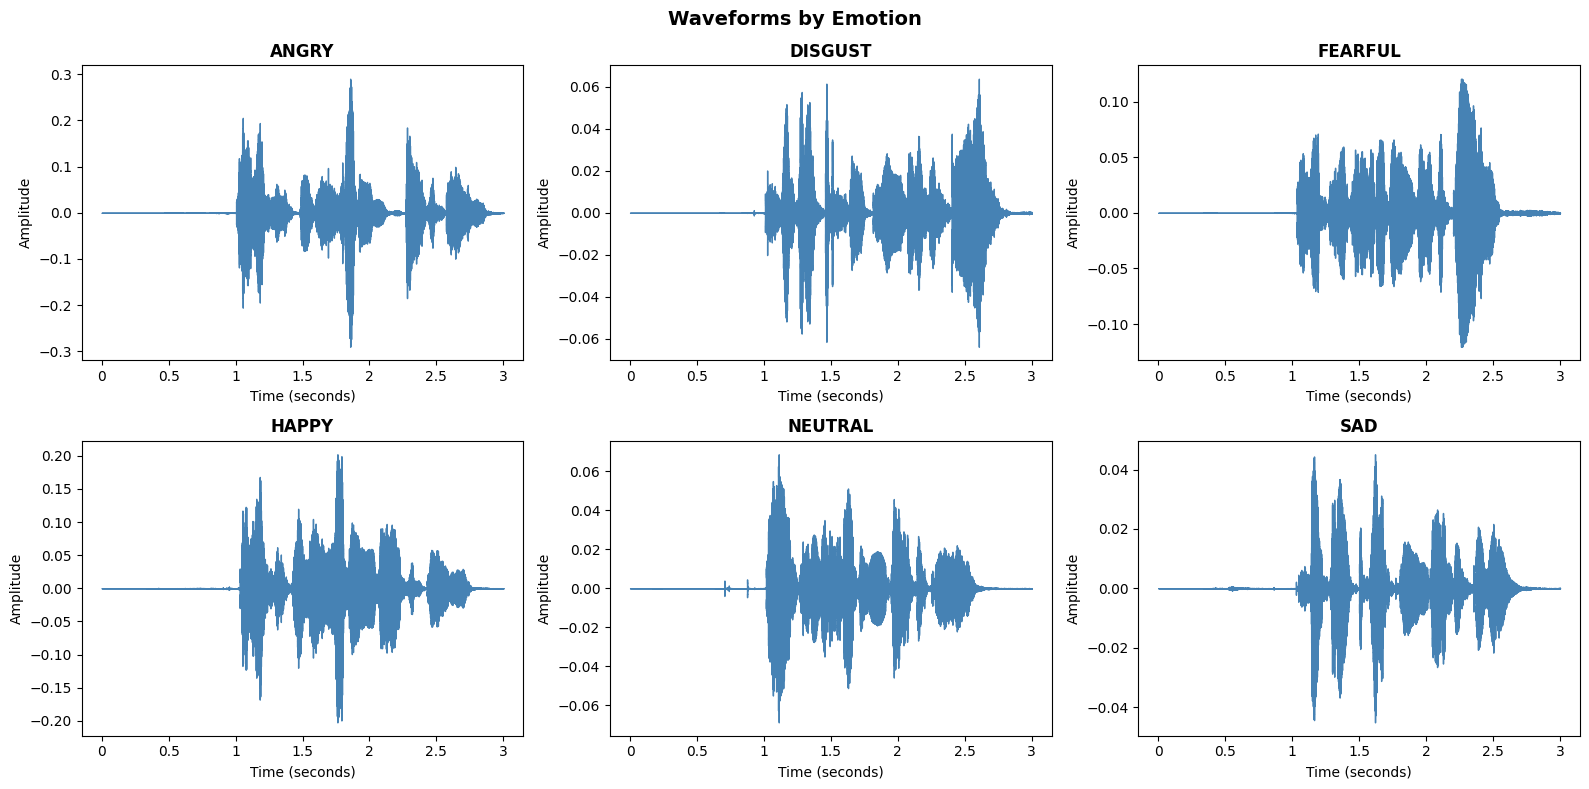

In [ ]:
emotions=sorted(df['emotion'].unique())

fig,axes = plt.subplots(2, 3, figsize=(16, 8))

axes = axes.flatten()

for idx, emotion in enumerate(emotions):
    ax = axes[idx]
    
    sample_path = df[df['emotion'] == emotion].iloc[0]['filepath']
    
    audio, sr = librosa.load(sample_path, sr=22050, duration=3)
    librosa.display.waveshow(audio, sr=sr, ax=ax, color='steelblue')
    
    ax.set_title(f'{emotion.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Amplitude')

plt.suptitle('Waveforms by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

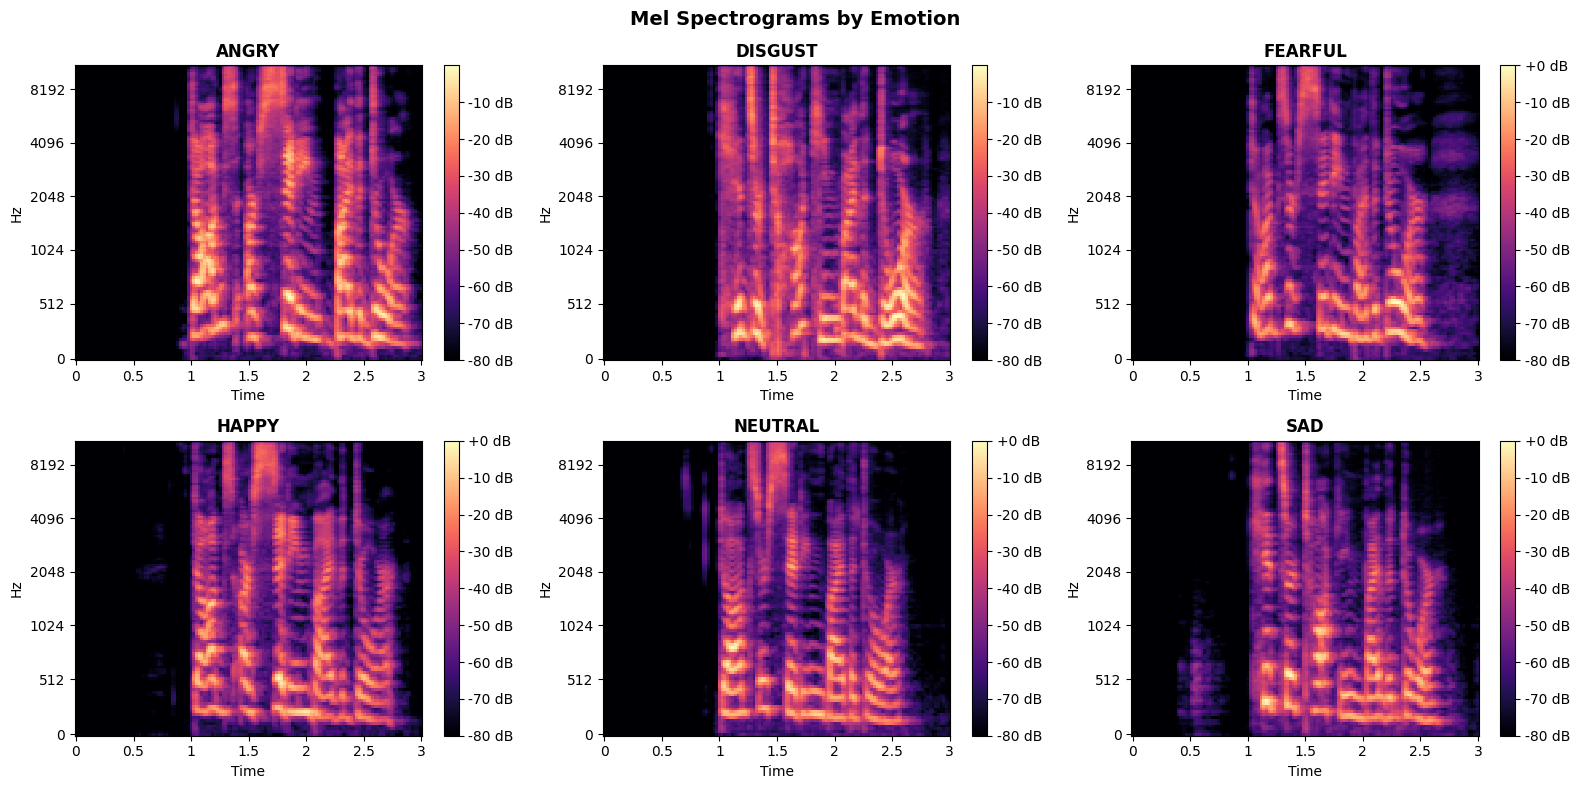

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, emotion in enumerate(emotions):
    ax = axes[idx]
    
    sample_path = df[df['emotion'] == emotion].iloc[0]['filepath']
    audio, sr = librosa.load(sample_path, sr=22050, duration=3)

    mel_spec = librosa.feature.melspectrogram(
        y=audio,    
        sr=sr,       
        n_mels=128   
    )

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    img = librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        x_axis='time',
        y_axis='mel',
        ax=ax
    )
    
    ax.set_title(f'{emotion.upper()}', fontsize=12, fontweight='bold')
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.suptitle('Mel Spectrograms by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

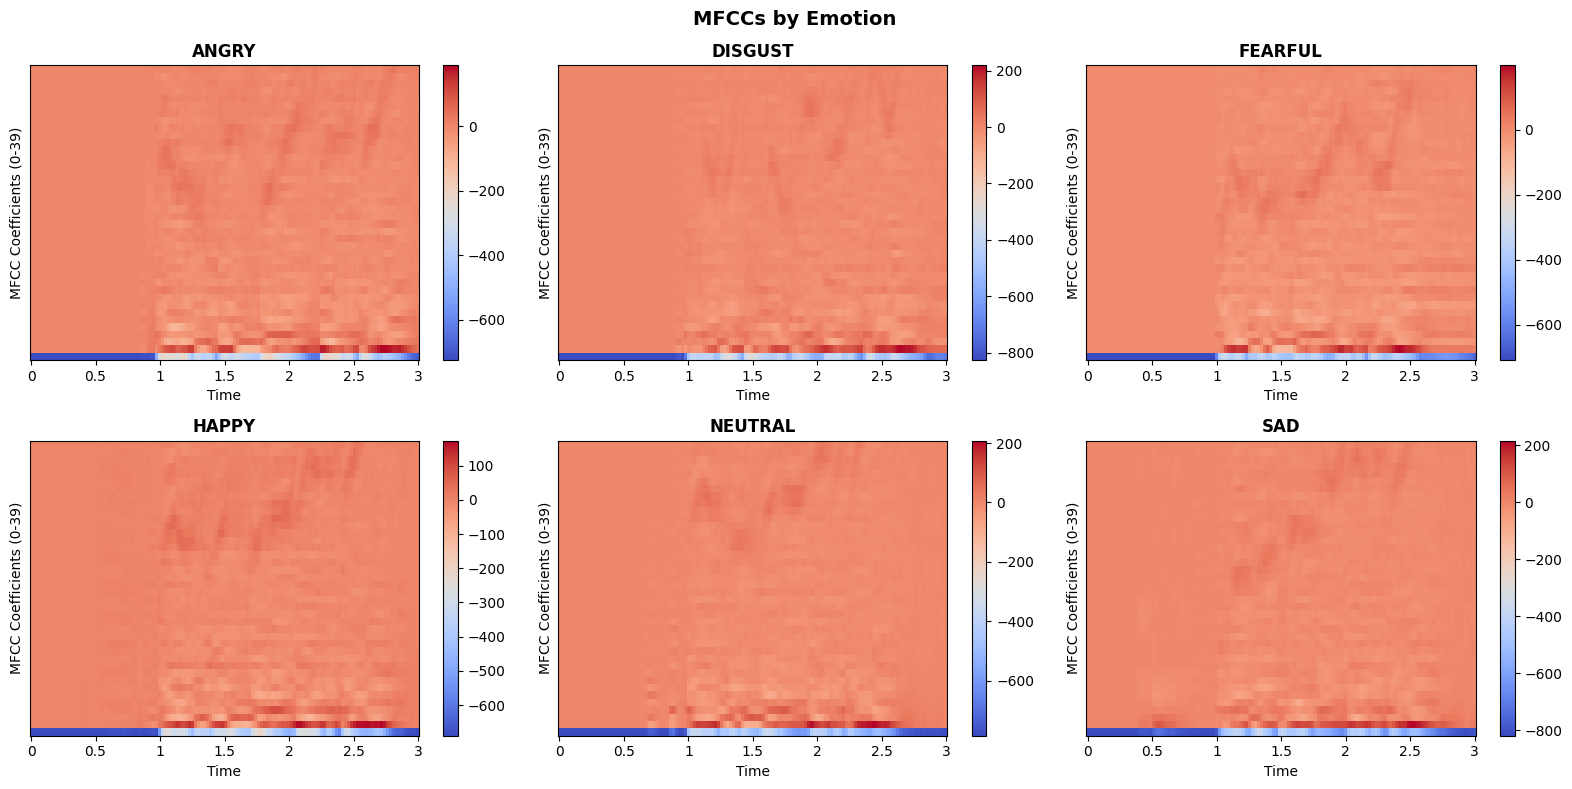

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, emotion in enumerate(emotions):
    ax = axes[idx]
    
    sample_path = df[df['emotion'] == emotion].iloc[0]['filepath']
    audio, sr = librosa.load(sample_path, sr=22050, duration=3)
    
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )
    
    img = librosa.display.specshow(
        mfcc,
        sr=sr,
        x_axis='time',
        ax=ax
    )
    
    ax.set_title(f'{emotion.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('MFCC Coefficients (0-39)')
    plt.colorbar(img, ax=ax)

plt.suptitle('MFCCs by Emotion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('../data', exist_ok=True)

save_path = '../data/dataset.csv'
df.to_csv(save_path, index=False)

print(f"Dataset saved!")


Dataset saved!

📊 Final Summary:
Total samples  : 14774
Emotions : ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
Sources : ['crema', 'ravdess', 'savee', 'tess']

Emotion breakdown:
  angry     :  2515  ████████████████
  fearful   :  2515  ████████████████
  disgust   :  2515  ████████████████
  sad       :  2515  ████████████████
  happy     :  2515  ████████████████
  neutral   :  2199  ██████████████
